In [ ]:
from pathlib import Path
import polars as pl
import pandas as pd
from scipy import stats
from matplotlib import pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
import patsy
from statsmodels.stats import multitest
import numpy as np
from joblib import Parallel, delayed
from sklearn.cross_decomposition import CCA
from cogmood_analysis.nonparam import run_reg_perms, run_reg_boots
from cogmood_analysis.permcca import permcca, semiortho, center, seber_cca
pl.Config.set_tbl_rows(100) 
pl.Config.set_tbl_cols(15) 


In [ ]:
dat 

In [42]:
task_dir = Path('../data/task/')
survey_dat = pl.read_csv('../data/survey/survey_responses.csv')
survey_dat = survey_dat.filter(~pl.col('sex_at_birth__prefer_not_to_answer'))
survey_dat = survey_dat.with_columns(
    age2 = pl.col('age')**2,
    sex = pl.col('sex_at_birth__female'),
    age_sex = pl.col('sex_at_birth__female') * pl.col('age'),
    age2_sex = pl.col('sex_at_birth__female') * pl.col('age')**2,
    backfilled_prolific_screen_group = pl.col('prolific_screen_group').fill_null(pl.col('screen_group'))
)
survey_dat = survey_dat.filter(pl.col('backfilled_prolific_screen_group') != 'othermh')

In [43]:
# load and merge task data
bart_dat = pl.read_csv(task_dir / 'bart_results.csv').with_columns(
    sub_id=pl.col('subject'),
    bart__alpha=pl.col('map__alpha'),
    bart__gamma_neg=pl.col('map__gamma_neg'),
    bart__gamma_pos=pl.col('map__gamma_pos'),
    bart__tau=pl.col('map__tau'),
    bart__theta=pl.col('map__theta'),
    bart__sub_score=pl.col('sub_score'),
    bart__map_dif = pl.col('sub_score') - pl.col('map_mean'),
    bart__abs_map_dif = (pl.col('sub_score') - pl.col('map_mean')).abs(),
    bart__max_rhat=pl.col('max_rhat'),
)
bd_to_merge = bart_dat.select([
    'sub_id',
    'bart__alpha',
    'bart__gamma_neg',
    'bart__gamma_pos',
    'bart__tau',
    'bart__theta',
    'bart__sub_score',
    'bart__map_dif',
    'bart__abs_map_dif',
    'bart__max_rhat'
])
dat = survey_dat.join(bd_to_merge, on='sub_id', how='inner')
rdm_dat = pl.read_csv(task_dir / 'rdm_results.csv').with_columns(
    sub_id=pl.col('subject'),
    rdm__v0=pl.col('map__v0'),
    rdm__w_d=pl.col('map__w_d'),
    rdm__w_s=pl.col('map__w_s'),
    rdm__t0=pl.col('map__t0'),
    rdm__sigma=pl.col('map__sigma'),
    rdm__sigma_timer=pl.col('map__sigma_timer'),
    rdm__v_timer=pl.col('map__v_timer'),
    rdm__sub_score=pl.col('sub_score'),
    rdm__map_dif = pl.col('sub_score') - pl.col('map_mean'),
    rdm__abs_map_dif = (pl.col('sub_score') - pl.col('map_mean')).abs(),
    rdm__max_rhat=pl.col('max_rhat'),

)
rd_to_merge = rdm_dat.select([
    'sub_id',
    'rdm__v0',
    'rdm__w_d',
    'rdm__w_s',
    'rdm__t0',
    'rdm__sigma',
    'rdm__sigma_timer',
    'rdm__v_timer',
    'rdm__sub_score',
    'rdm__map_dif',
    'rdm__abs_map_dif',
    'rdm__max_rhat'
])
dat = dat.join(rd_to_merge, on='sub_id', how='inner')
cab_dat = pl.read_csv(task_dir / 'cab_results.csv').with_columns(
    sub_id=pl.col('subject'),
    cab__a=pl.col('map__a'),
    cab__alpha=pl.col('map__alpha'),
    cab__gamma=pl.col('map__gamma'),
    cab__kappa=pl.col('map__kappa'),
    cab__lam=pl.col('map__lam'),
    cab__nu=pl.col('map__nu'),
    cab__rho=pl.col('map__rho'),
    cab__t0=pl.col('map__t0'),
    cab__tau=pl.col('map__tau'),
    cab__w=pl.col('map__w'),
    cab__sub_score=pl.col('sub_score'),
    cab__map_dif = pl.col('sub_score') - pl.col('map_mean'),
    cab__abs_map_dif = (pl.col('sub_score') - pl.col('map_mean')).abs(),
    cab__max_rhat=pl.col('max_rhat'),
)
cd_to_merge = cab_dat.select([
    'sub_id',
    'cab__a',
    'cab__alpha',
    'cab__gamma',
    'cab__kappa',
    'cab__lam',
    'cab__nu',
    'cab__rho',
    'cab__t0',
    'cab__tau',
    'cab__w',
    'cab__sub_score',
    'cab__map_dif',
    'cab__abs_map_dif',
    'cab__max_rhat'
])
dat = dat.join(cd_to_merge, on='sub_id', how='inner')
flkr_dat = pl.read_csv(task_dir / 'flkr_results.csv')
flkr_dat = survey_dat.join(flkr_dat, on='sub_id', how='inner')
flkr_dat = flkr_dat.with_columns(
    flkr__r=pl.col('map__r'),
    flkr__p=pl.col('map__p'),
    flkr__sd0=pl.col('map__sd0'),
    flkr__K=pl.col('map__K'),
    flkr__L=pl.col('map__L'),
    flkr__thresh=pl.col('map__thresh'),
    flkr__alpha=pl.col('map__alpha'),
    flkr__t0=pl.col('map__t0'),
    flkr__map_dif = pl.col('total') - pl.col('total_map'),
    flkr__abs_map_dif = (pl.col('total') - pl.col('total_map')).abs(),
    flkr__sub_score = pl.col('total'),
    flkr__max_rhat = pl.col('max_rhat')

)
fd_to_merge = flkr_dat.select([
    'sub_id',
    'flkr__r',
    'flkr__p',
    'flkr__sd0',
    'flkr__K',
    'flkr__L',
    'flkr__thresh',
    'flkr__alpha',
    'flkr__t0',
    'flkr__sub_score',
    'flkr__map_dif',
    'flkr__abs_map_dif',
    'flkr__max_rhat'
])
dat = dat.join(fd_to_merge, on='sub_id', how='inner')

In [44]:
survey_dat.shape

(4039, 442)

In [45]:
all_survey_scores = [
    'phq8',
    'todayphq8',
    'gad7',
    'todaygad7',
    'baars_hyperactivity',
    'todaybaars_hyperactivity',
    'baars_impulsivity',
    'todaybaars_impulsivity',
    'baars_inattentive',
    'todaybaars_inattentive',
    'baars_sct',
    'todaybaars_sct',
    'hitop_anhdep',
    'todayhitop_anhdep',
    'hitop_sepinsec',
    'todayhitop_sepinsec',
    'hitop_anxwor',
    'todayhitop_anxwor',
    'hitop_welbe',
    'todayhitop_welbe',
    'hitop_appgn',
    'todayhitop_appgn',
    'hitop_socanx',
    'todayhitop_socanx',
    'hitop_hypsom',
    'todayhitop_hypsom',
    'hitop_cogprb',
    'todayhitop_cogprb',
    'hitop_indec',
    'todayhitop_indec',
    'hitop_appls',
    'todayhitop_appls',
    'hitop_insom',
    'todayhitop_insom',
    'hitop_shmglt',
    'todayhitop_shmglt',
    'hitop_sitphb',
    'todayhitop_sitphb', 
    'hitop_panic',
    'todayhitop_panic',
]

qc_scores = [
    'max_rhat',
    'map_dif',
    'abs_map_dif'
]

today_scores = [ss for ss in all_survey_scores if 'today' in ss]
survey_scores = [ss for ss in all_survey_scores if 'today' not in ss]

In [47]:
x_cols = [
    'bart__alpha',
    'bart__gamma_neg',
    'bart__gamma_pos',
    'bart__tau',
    'bart__theta',
    'rdm__v0',
    'rdm__w_d',
    'rdm__w_s',
    'rdm__t0',
    'rdm__sigma',
    'rdm__sigma_timer',
    'rdm__v_timer',
    'cab__a',
    'cab__alpha',
    'cab__gamma',
    'cab__kappa',
    'cab__lam',
    'cab__nu',
    'cab__rho',
    'cab__t0',
    'cab__tau',
    'cab__w',
    'flkr__r',
    'flkr__p',
    'flkr__sd0',
    'flkr__K',
    'flkr__L',
    'flkr__thresh',
    'flkr__alpha',
    'flkr__t0',
]
y_cols = survey_scores
nus_cols = [
    'age',
    'age2',
    'sex',
    'age_sex',
    'age2_sex'
]

score_lut = {
    'phq8': 'PHQ-8',
    'gad7': 'GAD-7',
    'hitop': 'HiTOP Total',
    'baars': 'BAARS total',
    'baars_hyperactivity': 'B-Hyper.',
    'baars_inattentive': 'B-Inatt.',
    'baars_impulsivity': 'B-Impuls.',
    'baars_sct': 'B-SCT',
    'hitop_anhdep': 'Anh. Dep.',
    'hitop_anxwor': 'Anx. Wor.',
    'hitop_appgn': 'App. Gain',
    'hitop_appls': 'App. Loss',
    'hitop_cogprb': 'Cog. Prob.',
    'hitop_hypsom': 'Hyposom.',
    'hitop_indec': 'Indecis.',
    'hitop_insom': 'Insom.',
    'hitop_socanx': 'Soc. Anx.',
    'hitop_shmglt': 'Shame/Glt.',
    'hitop_sepinsec': 'Sep. Insec.',
    'hitop_sitphb': 'Sit. Phob.',
    'hitop_panic': 'Panic',
    'hitop_welbe': 'Well Being',
}
param_lut = {
    'rdm__t0': 'RDM- $t_0$',
    'rdm__v0': 'RDM- $v_0$',
    'rdm__w_d': 'RDM- $\\omega_d$',
    'rdm__w_s': 'RDM- $\\omega_s$',
    'rdm__sigma': 'RDM- $\\sigma$',
    'rdm__sigma_timer': 'RDM- $\\sigma_t$',
    'rdm__v_timer': 'RDM- $v_t$',
    
    'flkr__t0': 'FLKR- $t_0$',
    'flkr__thresh': 'FLKR- $\\alpha$',
    'flkr__L': 'FLKR- $\\beta$',
    'flkr__K': 'FLKR- $\\kappa$',
    'flkr__sd0': 'FLKR- $sd_0$',
    'flkr__p': 'FLKR- $p$',
    'flkr__r': 'FLKR- $r_d$',
    'flkr__alpha': 'FLKR- $n_0$',
    
    'cab__kappa': 'CAB- $\\kappa$',
    'cab__gamma': 'CAB- $\\gamma$',
    'cab__tau': 'CAB- $\\tau$',
    'cab__rho': 'CAB- $\\rho$',
    'cab__nu': 'CAB- $\\nu$',
    'cab__lam': 'CAB- $\\lambda$',
    'cab__alpha': 'CAB- $\\alpha$',
    'cab__a': 'CAB- $a$',
    'cab__w': 'CAB- $w$',
    'cab__t0': 'CAB- $t_0$',
    
    'bart__alpha': 'BART- $\\alpha$',
    'bart__gamma_pos': 'BART- $\\gamma +$',
    'bart__gamma_neg': 'BART- $\\gamma -$',
    'bart__theta': 'BART- $\\theta$',
    'bart__tau': 'BART- $\\tau$',
}

In [48]:
tdat = dat.with_columns(tmp_id = np.arange(len(dat)))

In [49]:
# move nosel subjects to the end to make things work
# these ids are chosen semi-randomly just to amke sure that there'a balance of men and women
nosel_ids = ['0u00itjgyz9wwodhvfl90ke7', 'ti2k0wix1d30oiqp9o3422h1', '6ap09882ff2j5n6y0emtd622', 'z8skdb2qhctb13je7y51fi77', 'z8skdb2qhctb13je7y51fi77']
sel_ids = [xx for xx in dat['sub_id'].to_list() if xx not in nosel_ids]
dat = pl.concat([dat.filter(pl.col('sub_id').is_in(sel_ids)), dat.filter(pl.col('sub_id').is_in(nosel_ids))])

In [50]:
n_perms = 1000
x = dat.select(x_cols).to_numpy()
x = (x - x.mean(0)) / x.std(0)
y = dat.select(y_cols).to_numpy()
y = (y - y.mean(0)) / y.std(0)
z = dat.select(nus_cols).to_numpy()
z = (z - z.mean(0)) / z.std(0)
dat_pd = dat.to_pandas().reset_index(drop=True)
dat_pd['tmp_index'] = dat_pd.reset_index(names='tmp_index').tmp_index
max_id = len(x) - z.shape[1]

In [51]:
perms = np.array([dat_pd.loc[dat_pd.tmp_index < max_id].groupby('backfilled_prolific_screen_group').tmp_index.sample(frac=1, replace=False).values for bid in range(n_perms)]).T.squeeze()
# set 0th perm to no perm
perms = np.hstack((np.arange(perms.shape[0])[:, np.newaxis], perms))
sel = dat_pd.tmp_index[dat_pd.tmp_index < max_id].to_numpy()

In [52]:
dat_pd.loc[~dat_pd.tmp_index.isin(sel), ['backfilled_prolific_screen_group' ]+ nus_cols]

,backfilled_prolific_screen_group,age,age2,sex,age_sex,age2_sex
2783,anx,64.0,4096.0,False,0.0,0.0
2784,dep_anx_atn,36.0,1296.0,True,36.0,1296.0
2785,hv,47.0,2209.0,True,47.0,2209.0
2786,dep_anx,37.0,1369.0,True,37.0,1369.0
2787,anx,21.0,441.0,False,0.0,0.0


In [15]:
p, r, A, B, U, V, rperm_list, rperm_list_projected = permcca(y, x, Z=z, nP=n_perms+1, Pset=perms, Sel=sel, return_projected_rperm=True)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1001/1001 [21:16<00:00,  1.27s/it]


In [16]:
cc_cols = [f'cc{i:02d}' for i in np.arange(A.shape[1])]


<Axes: >

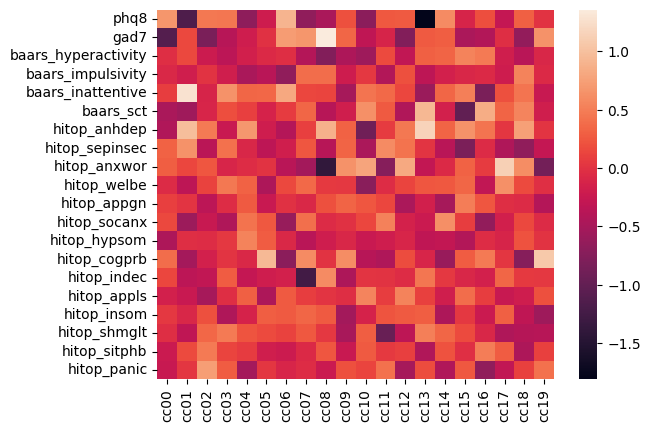

In [56]:
Adf = pd.DataFrame(
    data=A,
    columns=cc_cols,
    index=y_cols
)
sns.heatmap(Adf)

<Axes: >

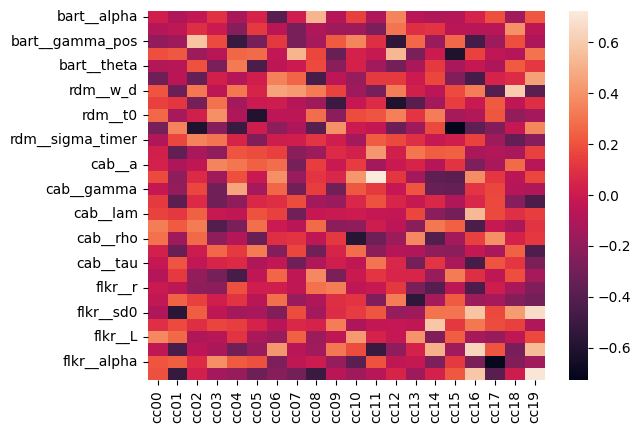

In [57]:
Bdf = pd.DataFrame(
    data=B,
    columns=cc_cols,
    index=x_cols
)
sns.heatmap(Bdf)

In [58]:
sig_map = p < 0.05
n_sig = sig_map.sum()

In [59]:
A.shape, B.shape, r.shape, U.shape, V.shape

((20, 20), (30, 20), (20,), (2788, 20), (2788, 20))

In [60]:
cc_cols = [f'cc{i:02d}' for i in np.arange(A.shape[1])]


In [128]:
Yc.shape

(2783, 20)

In [129]:
Qz = semiortho(center(z), sel) 
resY = Qz.T @ center(y)
resX = Qz.T @ center(x)
Us = U[sel]
Vs = V[sel]
Xc = resX
Yc = resY
k = n_sig
Uk = Us[:, :k]
Vk = Vs[:, :k]
Rk = np.diag(r[:k])

LX = Xc.T @ Vk @ np.linalg.pinv(Vk.T @ Vk)
LY = Yc.T @ Uk @ np.linalg.pinv(Uk.T @ Uk)

# 1) residuals after reconstruction from own canonical subspace
Xhat = Vk @ LX.T
Yhat = Uk @ LY.T
EX = Xc - Xhat
EY = Yc - Yhat

# 2) residuals after removing only shared CCA structure
Xhat_shared = Uk @ Rk @ LX.T      # assumes standard normalization of U,V
Yhat_shared = Vk @ Rk @ LY.T
EX_shared = Xc - Xhat_shared
EY_shared = Yc - Yhat_shared
print(f'Cog %var in subspace: {(Xc.var() - EX.var()) * 100:0.2f}%')
print(f'Symptom %var in subspace: {(Yc.var() - EY.var()) * 100:0.2f}%')
print(f'Cog %var explained by symptom subspace: {(Xc.var() - EX_shared.var()) * 100:0.2f}%')
print(f'Symtpom %var explained by cog subspace: {(Yc.var() - EY_shared.var()) * 100:0.2f}%')

Cog %var in subspace: 10.32%
Symptom %var in subspace: 17.68%
Cog %var explained by symptom subspace: 0.44%
Symtpom %var explained by cog subspace: 0.80%


In [62]:
N = len(x)
R = S = z.shape[1]

In [63]:
# check if U and V are normalized
Ucheck = (Us.T @ Us) / (N-R)
Vcheck = (Vs.T @ Vs) / (N-S)

<Axes: >

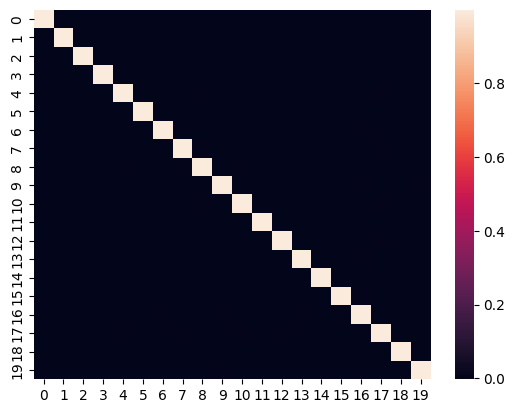

In [64]:
sns.heatmap(Ucheck)

<Axes: >

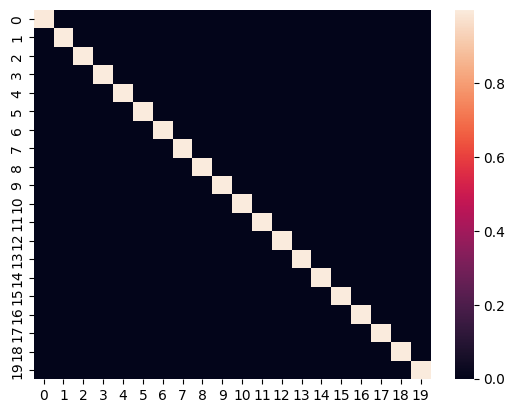

In [65]:
sns.heatmap(Vcheck)

<Axes: >

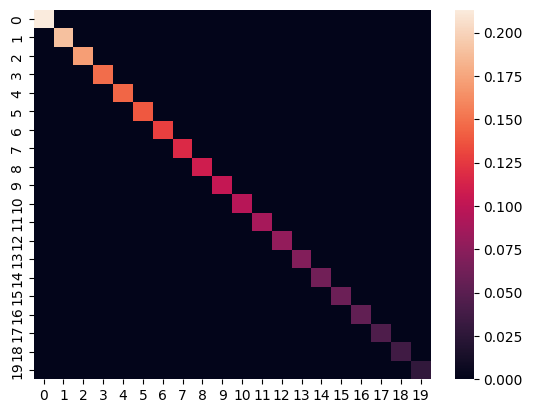

In [66]:
sns.heatmap(1/len(Us) * (U.T @ V))

In [67]:
Lx = resX.T @ Us @ np.linalg.pinv(Us.T @ Us)
Ly = resY.T @ Vs @ np.linalg.pinv(Vs.T @ Vs)
R = np.diag(r)

# since normalization is correct, this simplifies
# U_hat = Vs @ np.linalg.pinv(Vs.T @ Vs) @ Vs.T @ Us
# V_hat = Us @ np.linalg.pinv(Us.T @ Us) @ Us.T @ Vs
U_hat = Vs @ R
V_hat = Us @ R

X_hatshared = U_hat @ Lx.T
Y_hatshared = V_hat @ Ly.T

In [68]:
X_shared_resid = resX - X_hatshared
Y_shared_resid = resY - Y_hatshared

In [69]:
resX.var(), X_shared_resid.var(), resX.var() - X_shared_resid.var()

(np.float64(0.9885320660216694),
 np.float64(0.9679218952940979),
 np.float64(0.020610170727571542))

In [70]:
resY.var(), Y_shared_resid.var(), resY.var() - Y_shared_resid.var()

(np.float64(0.9370850159812106),
 np.float64(0.9037508194142038),
 np.float64(0.03333419656700687))

<Axes: >

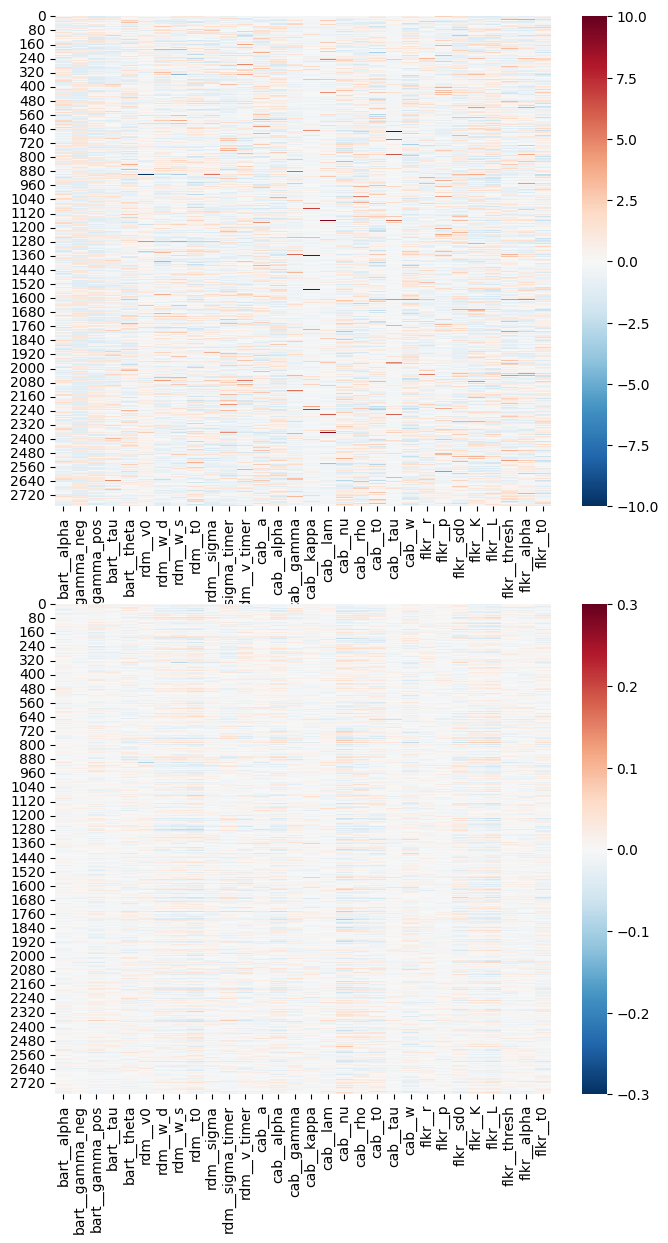

In [71]:
resXdf = pd.DataFrame(
    data=resX,
    columns=x_cols
)
hsXdf = pd.DataFrame(
    data=X_hatshared,
    columns=x_cols
)
fig, axes = plt.subplots(2, figsize=(8, 14))
sns.heatmap(resXdf, ax=axes[0], cmap='RdBu_r', vmin=-10, vmax=10)
sns.heatmap(hsXdf, ax=axes[1], cmap='RdBu_r', vmin=-0.3, vmax=0.3)

<Axes: >

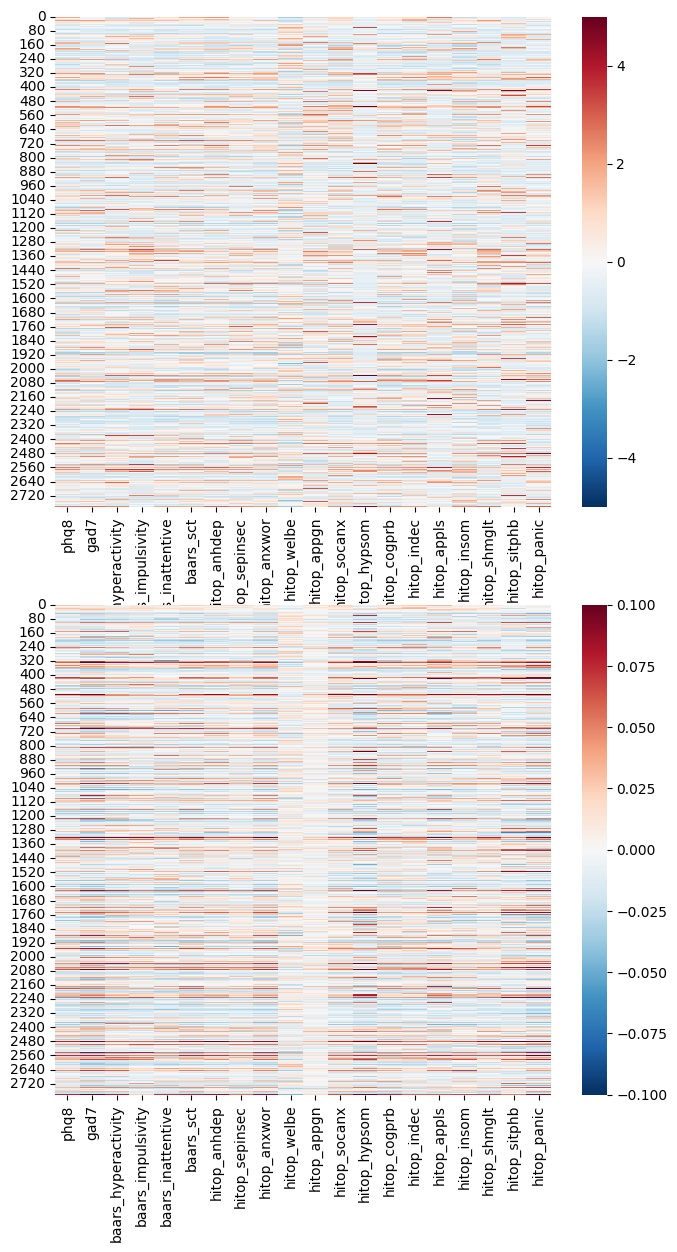

In [72]:
resYdf = pd.DataFrame(
    data=resY,
    columns=y_cols
)
hsYdf = pd.DataFrame(
    data=Y_hatshared,
    columns=y_cols
)
fig, axes = plt.subplots(2, figsize=(8, 14))
sns.heatmap(resYdf, ax=axes[0], cmap='RdBu_r', vmin=-5, vmax=5)
sns.heatmap(hsYdf, ax=axes[1], cmap='RdBu_r', vmin=-0.1, vmax=0.1)

['PHQ-8',
 'GAD-7',
 'B-Hyper.',
 'B-Impuls.',
 'B-Inatt.',
 'B-SCT',
 'Anh. Dep.',
 'Sep. Insec.',
 'Anx. Wor.',
 'Well Being',
 'App. Gain',
 'Soc. Anx.',
 'Hyposom.',
 'Cog. Prob.',
 'Indecis.',
 'App. Loss',
 'Insom.',
 'Shame/Glt.',
 'Sit. Phob.',
 'Panic']

In [112]:
y_plot_cols = [score_lut[cc] for cc in y_cols]
x_plot_cols = [param_lut[cc] for cc in x_cols]
# Weights for transforming y and x into their subspaces
Adf = pd.DataFrame(
    data=A[:, :n_sig],
    index=y_plot_cols,
    columns=cc_cols[:n_sig]
)
Bdf = pd.DataFrame(
    data=B[:, :n_sig],
    index=x_plot_cols,
    columns=cc_cols[:n_sig]
)

# Correlation of cannonical compenents with their features
Lxdf = pd.DataFrame(
    data=np.corrcoef(Xc.T, Vk.T)[:Xc.shape[1], Xc.shape[1]:],
    index=x_plot_cols,
    columns=cc_cols[:n_sig]
)
Lydf = pd.DataFrame(
    data=np.corrcoef(Yc.T, Uk.T)[:Yc.shape[1], Yc.shape[1]:],
    index=y_plot_cols,
    columns=cc_cols[:n_sig]
)

# Cross correlation of canonical components with the other features
CLxdf = pd.DataFrame(
    data=np.corrcoef(Xc.T, Uk.T)[:Xc.shape[1], Xc.shape[1]:],
    index=x_plot_cols,
    columns=cc_cols[:n_sig]
)
CLydf = pd.DataFrame(
    data=np.corrcoef(Yc.T, Vk.T)[:Yc.shape[1], Yc.shape[1]:],
    index=y_plot_cols,
    columns=cc_cols[:n_sig]
)

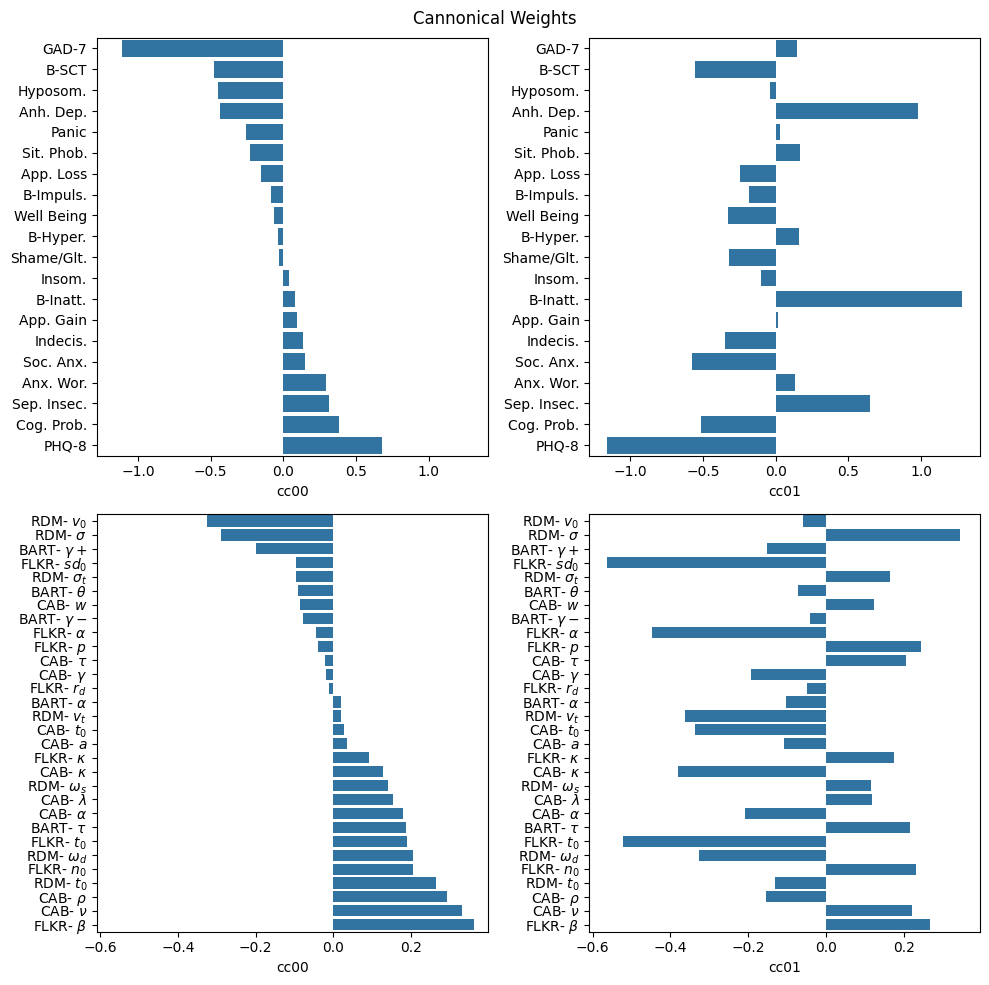

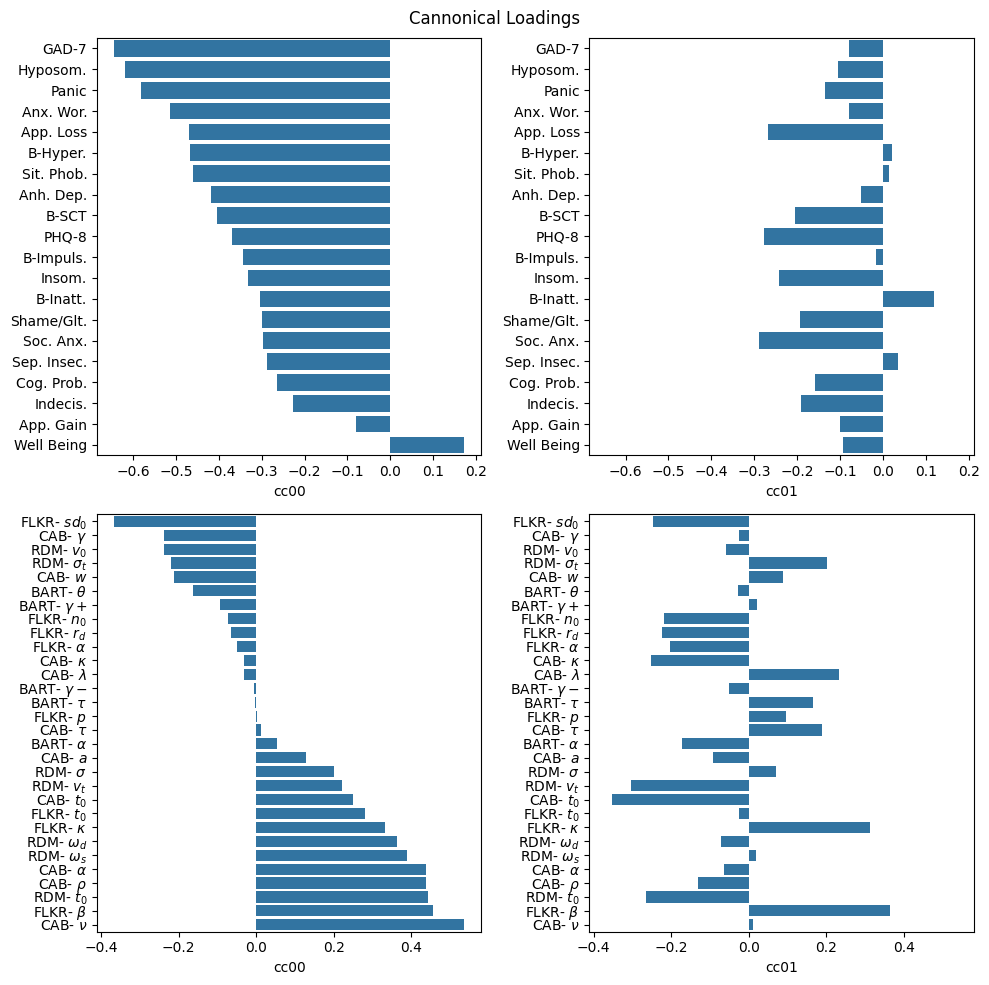

In [127]:
def plot_cannonical_bars(xdf, ydf, title, sort=None):
    
    fig, axes = plt.subplots(2, sig_map.sum(), figsize=(5 * sig_map.sum(), 10))
    tempx = xdf.copy()
    tempy = ydf.copy()
    if sort is not None:
        if sort > len(tempx):
            raise ValueError("sort must be None or an index of which canonical corelate you want to sort by")
        tempx = tempx.sort_values(tempx.columns[sort])
        tempy = tempy.sort_values(tempy.columns[sort])

    for df, axrow in zip([tempx, tempy], axes):
        rowxmax = 0
        rowxmin = 0
        for cc, ax in zip(df.columns, axrow):
            sns.barplot(data=df, x=cc, y=df.index, ax=ax)
            xmin, xmax = ax.get_xlim()
            rowxmax = max(xmax, rowxmax)
            rowxmin = min(xmin, rowxmin)
        for ax in axrow:
            ax.set_xlim((rowxmin, rowxmax))
            ax.set_ylabel(None)
    fig.suptitle(title)
    fig.tight_layout()
    return fig
fig = plot_cannonical_bars(Adf, Bdf, 'Cannonical Weights', sort=0)
fig = plot_cannonical_bars(Lydf, Lxdf, 'Cannonical Loadings', sort=0)

<Axes: >

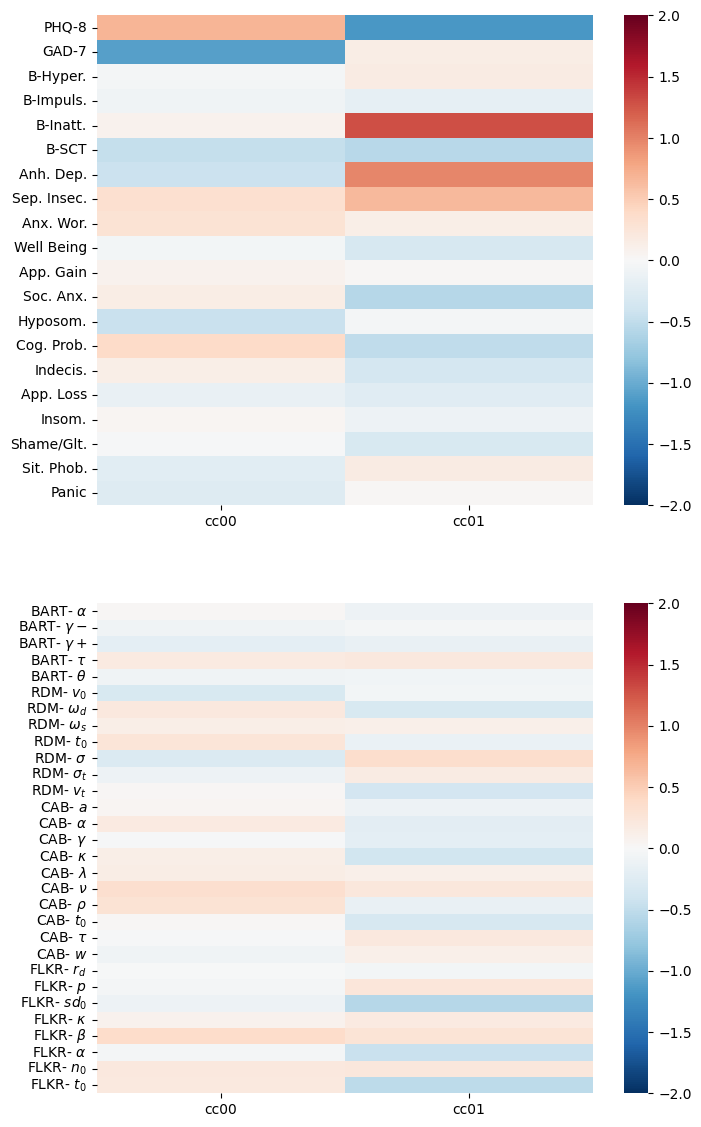

In [78]:
scale = 2
fig, axes = plt.subplots(2, figsize=(8, 14))
sns.heatmap(Adf, ax=axes[0], cmap='RdBu_r', vmin=-scale, vmax=scale)
sns.heatmap(Bdf, ax=axes[1], cmap='RdBu_r', vmin=-scale, vmax=scale)

<Axes: >

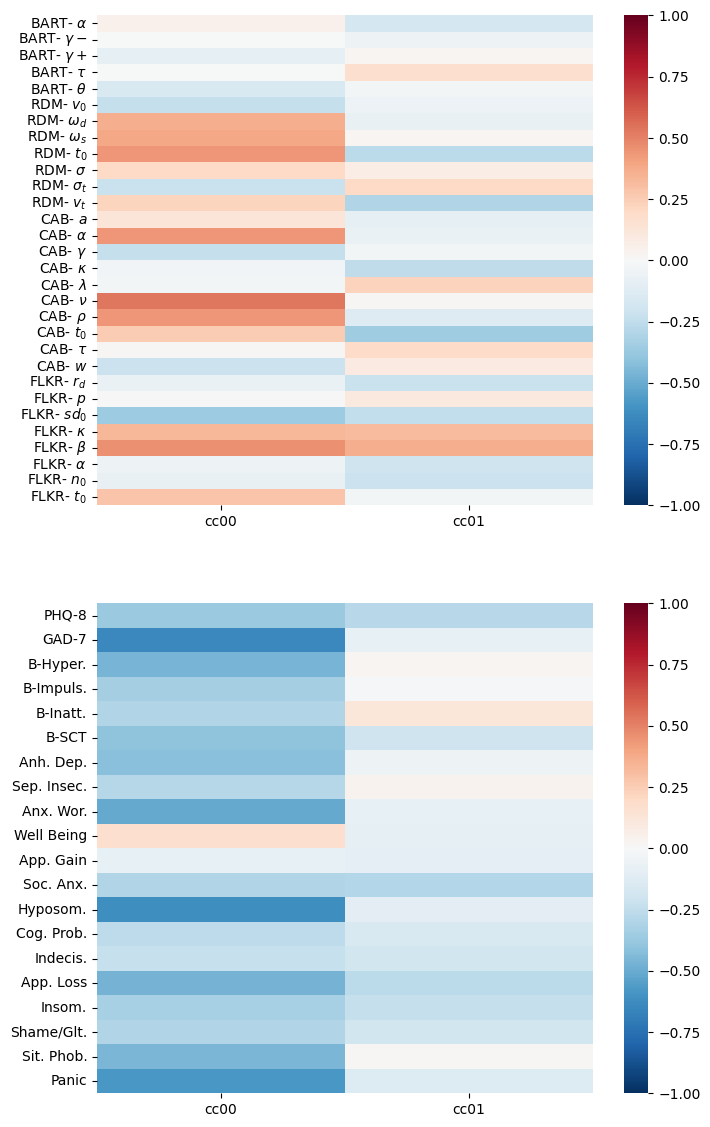

In [85]:
scale=1
fig, axes = plt.subplots(2, figsize=(8, 14))
sns.heatmap(Lxdf, ax=axes[0], cmap='RdBu_r', vmin=-scale, vmax=scale)
sns.heatmap(Lydf, ax=axes[1], cmap='RdBu_r', vmin=-scale, vmax=scale)

<Axes: >

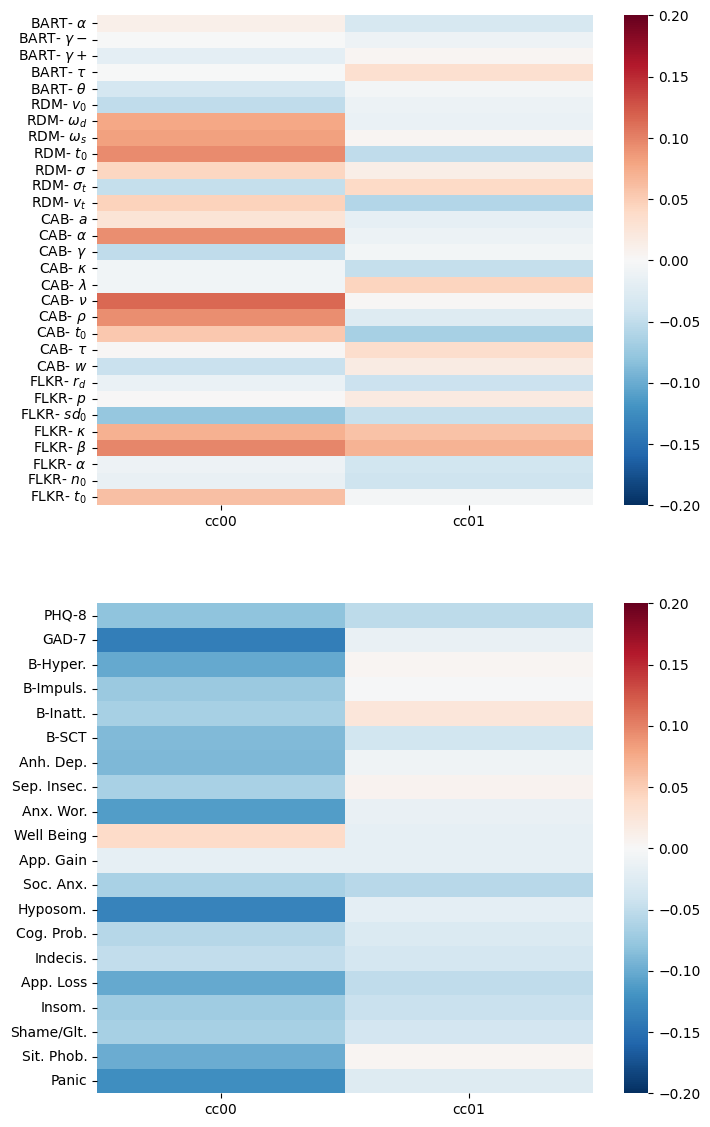

In [86]:
scale=0.2
fig, axes = plt.subplots(2, figsize=(8, 14))
sns.heatmap(CLxdf, ax=axes[0], cmap='RdBu_r', vmin=-scale, vmax=scale)
sns.heatmap(CLydf, ax=axes[1], cmap='RdBu_r', vmin=-scale, vmax=scale)

<Axes: xlabel='cc01', ylabel='None'>

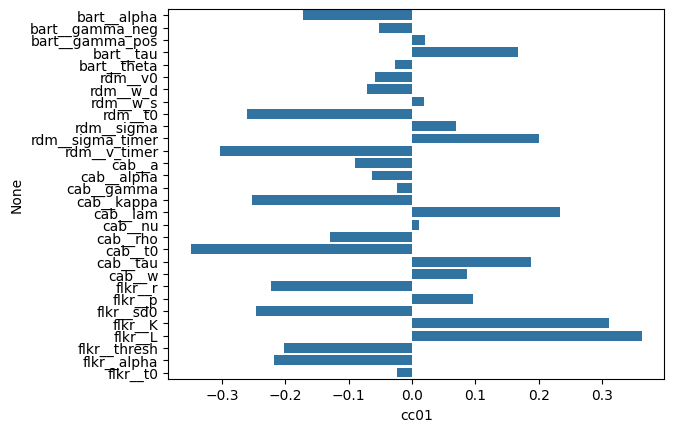

In [87]:
sns.barplot(data=Lxdf, x='cc01', y=Lxdf.index)

<Axes: xlabel='cc00', ylabel='None'>

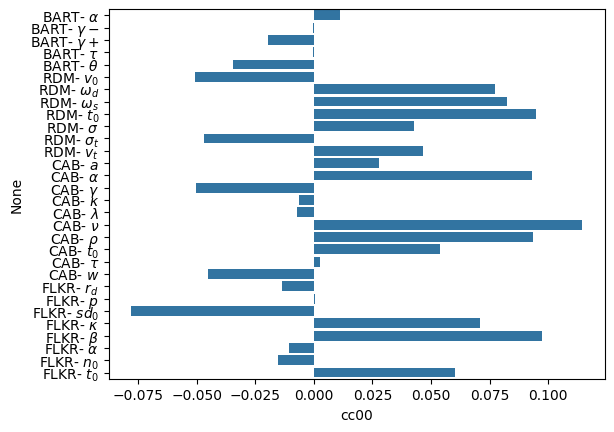

In [92]:
sns.barplot(data=CLxdf, x='cc00', y=CLxdf.index)

<Axes: xlabel='cc01', ylabel='None'>

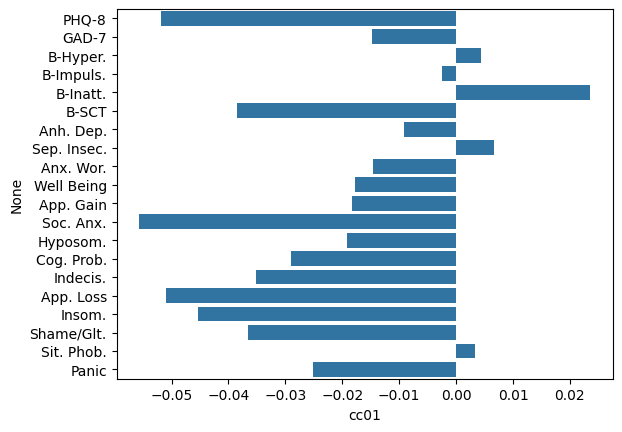

In [91]:
sns.barplot(data=CLydf, x='cc01', y=CLydf.index)

In [66]:
RDx.sum(), RDy.sum()

(np.float64(0.00019087389875821237), np.float64(0.00029359470337650883))

In [72]:
Lxdf = pd.DataFrame(
    data=Lx,
    index=x_cols,
    columns=cc_cols[:-1]
)
Lydf = pd.DataFrame(
    data=Ly,
    index=y_cols,
    columns=cc_cols[:-1]
)

In [73]:
Lxdf

,cc00,cc01,cc02,cc03,cc04,cc05,cc06,cc07,cc08,cc09,cc10,cc11,cc12,cc13,cc14,cc15,cc16,cc17
bart__alpha,0.029256,0.010134,0.027109,-0.001764,0.027829,0.006591,-0.042317,-0.023374,-0.030156,-0.015899,-0.027592,0.023990,-0.044994,0.018810,-0.016231,0.020928,0.015817,-0.016666
bart__gamma_neg,0.008360,0.029486,0.013595,0.027406,0.005322,0.007233,-0.025618,0.016334,-0.016898,-0.015912,-0.004091,0.019319,-0.022760,0.011383,-0.006851,0.009727,0.025081,-0.006811
bart__gamma_pos,0.005160,-0.008845,0.001113,0.038868,0.008209,-0.008831,0.014808,-0.010121,-0.022360,0.002174,0.002529,-0.001827,-0.004982,0.007029,0.002901,0.007793,-0.003347,-0.002121
bart__tau,-0.008461,-0.022253,-0.004067,0.027152,-0.026002,-0.009733,-0.000740,-0.002237,-0.008006,0.015582,-0.008578,-0.006917,0.025705,-0.003980,0.006566,-0.004576,-0.003987,0.014668
bart__theta,-0.004420,-0.029531,0.010228,-0.068984,-0.008732,0.015412,0.027023,-0.022054,0.046490,-0.016368,-0.025517,-0.002028,-0.017582,0.017966,-0.001807,0.013785,0.008556,-0.034928
rdm__v0,-0.028143,0.019964,-0.026264,0.038801,-0.004747,-0.015313,0.049985,0.053617,-0.001885,0.025210,0.023548,-0.021272,0.041773,-0.016106,0.015956,-0.032893,-0.010667,0.034361
rdm__w_d,0.045010,-0.049003,0.028154,0.006710,-0.020347,0.013717,-0.035885,-0.047366,-0.028778,-0.027087,-0.004524,0.025174,-0.001505,0.017229,-0.017264,0.034577,0.009852,-0.035274
rdm__w_s,0.039919,-0.044635,0.039112,-0.023096,-0.034486,0.015848,-0.037248,-0.050562,-0.032272,-0.020769,-0.024682,0.037947,0.002636,0.030767,-0.038986,0.038545,0.023457,-0.035755
rdm__t0,0.025439,-0.056551,0.028996,-0.036613,0.001804,0.007427,-0.048614,-0.027182,-0.024299,-0.006191,-0.016976,0.028052,-0.001156,0.012620,-0.009483,0.018071,0.014876,-0.039619
rdm__sigma,0.042436,-0.010477,0.035202,-0.031794,-0.005655,0.030783,-0.042642,-0.032826,-0.012637,-0.040851,-0.008963,0.036584,-0.053707,0.023889,-0.022513,0.043583,0.026594,-0.040491


<Axes: xlabel='cc00', ylabel='None'>

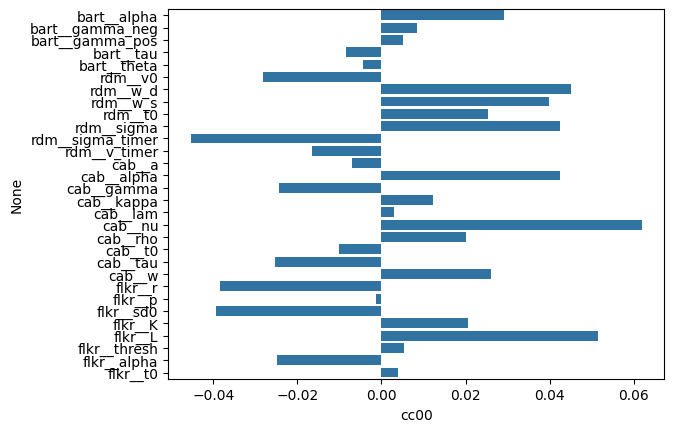

In [77]:
sns.barplot(data=Lxdf, x='cc00', y=Lxdf.index)

<Axes: xlabel='cc00', ylabel='None'>

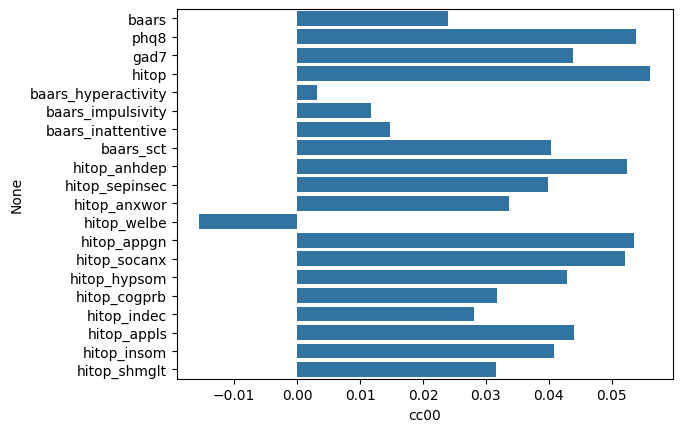

In [78]:
sns.barplot(data=Lydf, x='cc00', y=Lydf.index)

In [186]:
import scipy

In [194]:
def seber_cca(Y, X, R, S):
    N = Y.shape[0]
    Qy, Ry, iY = scipy.linalg.qr((Y), mode='economic', pivoting=True)
    Qx, Rx, iX = scipy.linalg.qr((X), mode='economic', pivoting=True)
    K = min(np.linalg.matrix_rank(Y), np.linalg.matrix_rank(X))
    QyTQx = Qy.T @ Qx
    if K <= 6 or K == np.min(QyTQx.shape):
        L, D, MT = scipy.linalg.svd(QyTQx, which='LM')
    else:
        L, D, MT = scipy.sparse.linalg.svds(QyTQx, k=K, which='LM')
    # svds does NOT sort singular values descending
    idx = np.argsort(D)[::-1]
    D = D[idx]
    L = L[:, idx]
    MT = MT[idx, :]

    cc = np.minimum(np.maximum(D[:K], 0), 1)
    A = np.linalg.pinv(Ry) @ (L[:, :K]) * np.sqrt(N - R)
    B = np.linalg.pinv(Rx) @ (MT[:K, :].T) * np.sqrt(N - S)
    A = A[iY]
    B = B[iX]
    return A, B, cc

In [195]:
wA, wB, wr = seber_cca(y, x, 0, 0)

In [196]:
wr

array([0.29170915, 0.24525782, 0.19579057, 0.18521268, 0.17572961,
       0.17230671, 0.15593608, 0.14502445, 0.13334314, 0.12217654,
       0.10660749, 0.09621326, 0.08954616, 0.07808471, 0.07692784,
       0.07063364, 0.06377289, 0.04844937, 0.0455468 ])

In [161]:
skcca = CCA(n_components=19)
skx_score, sky_score = skcca.fit_transform(x, y)

In [183]:
chatA, chatB, chatr = chat_cca(y, x, 0, 0)

ValueError: solve: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (m,m),(m,n)->(m,n) (size 19 is different from 30)

In [181]:
np.diag(np.corrcoef(skx_score.T, sky_score.T)[:19, 19:])[::-1]

array([0.03760254, 0.0473178 , 0.06013476, 0.06840079, 0.07488093,
       0.07806213, 0.08666808, 0.09564418, 0.09990266, 0.11687618,
       0.12991058, 0.13867252, 0.15581604, 0.17098981, 0.17572493,
       0.18427361, 0.1956875 , 0.24523181, 0.29077523])

In [180]:
wr

array([0.0455468 , 0.04844937, 0.06377289, 0.07063364, 0.07692784,
       0.07808471, 0.08954616, 0.09621326, 0.10660749, 0.12217654,
       0.13334314, 0.14502445, 0.15593608, 0.17230671, 0.17572961,
       0.18521268, 0.19579057, 0.24525782, 0.29170915])

<Axes: >

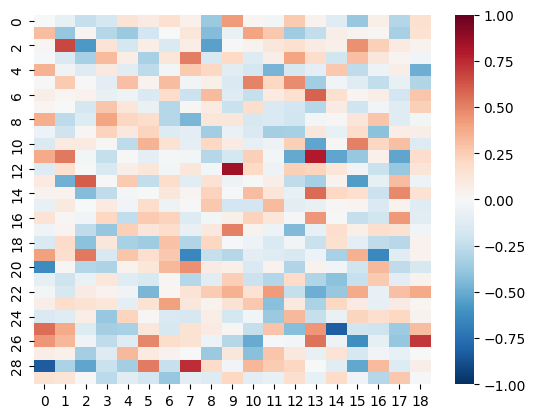

In [172]:
sns.heatmap(wB[:, ::-1], vmin=-1, vmax=1, cmap='RdBu_r')

<Axes: >

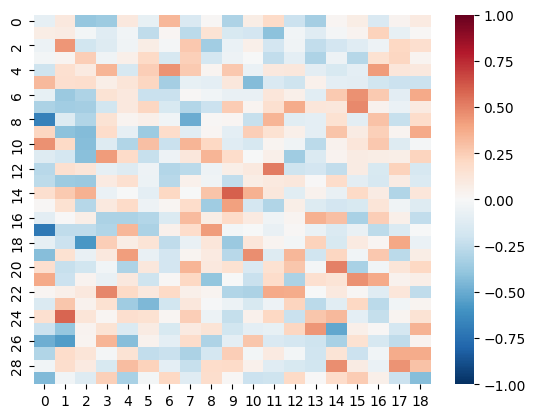

In [174]:
sns.heatmap(skcca.x_loadings_, vmin=-1, vmax=1, cmap='RdBu_r')

In [177]:
skcca.coef_.shape

(20, 30)

In [182]:
import numpy as np
from numpy.linalg import qr, matrix_rank, solve
from scipy.sparse.linalg import svds


def chat_cca(Y, X, R, S):
    """
    Compute Canonical Correlation Analysis (CCA), 
    translated from the provided MATLAB function.

    Parameters
    ----------
    Y : ndarray (N x p)
    X : ndarray (N x q)
    R : int
    S : int

    Returns
    -------
    A : ndarray
    B : ndarray
    cc : ndarray (canonical correlations)
    """

    N = Y.shape[0]

    # QR decompositions (economic mode)
    Qy, Ry = qr(Y, mode='reduced')
    Qx, Rx = qr(X, mode='reduced')

    # Numerical ranks
    rankY = matrix_rank(Y)
    rankX = matrix_rank(X)
    K = min(rankY, rankX)

    # Truncated SVD (largest singular values)
    # svds returns smallest singular values by default,
    # so we request largest via which='LM'
    L, D, M = svds(Qy.T @ Qx, k=K, which='LM')

    # svds does NOT sort singular values descending
    idx = np.argsort(D)[::-1]
    D = D[idx]
    L = L[:, idx]
    M = M[:, idx]

    # Canonical correlations
    cc = np.clip(D[:K], 0, 1)

    # Canonical coefficient matrices
    A = solve(Ry, L[:, :K]) * np.sqrt(N - R)
    B = solve(Rx, M[:, :K]) * np.sqrt(N - S)

    return A, B, cc